In [5]:
import numpy as np
import matplotlib.pyplot as plt

def f(t, y):
    return y**2 - 10

def f_prime(y):
    return 2*y

In [6]:
# Newton-Raphson for single step with Backward Euler
def backward_euler_step(f, y, t, h, tolerance=1e-6, max_iterations=50):
    y_next = y  # Initial guess
    for _ in range(max_iterations):
        g_val = y_next - y - h * f(t + h, y_next)
        g_prime_val = 1 - h * f_prime(y_next)
        
        if abs(g_prime_val) < tolerance:
            break
        
        y_new = y_next - g_val / g_prime_val
        
        if abs(y_new - y_next) < tolerance:
            return y_new
        
        y_next = y_new
    
    return y_next

In [7]:
# Adaptive Backward Euler
def backward_euler_adaptive(f, t0, tf, y0, h0, tolerance=1e-6, max_iterations=50):
    t_values = [t0]
    y_values = [y0]
    h = h0
    t = t0
    y = y0

    while t < tf:
        if t + h > tf:
            h = tf - t

        # Single step
        y_full = backward_euler_step(f, y, t, h, tolerance, max_iterations)

        # Two half-steps
        h_half = h / 2
        y_half_1 = backward_euler_step(f, y, t, h_half, tolerance, max_iterations)
        y_half_2 = backward_euler_step(f, y_half_1, t + h_half, h_half, tolerance, max_iterations)

        # Error estimate
        error = abs(y_full - y_half_2)

        if error > tolerance:
            h /= 2
            continue
        elif error < tolerance / 2:
            h *= 2

        # Accept step
        t += h
        y = y_half_2
        t_values.append(t)
        y_values.append(y)

    return np.array(t_values), np.array(y_values)

Final time: 5.785937499999983
Final value: -3.1622773593444227
Expected equilibrium: -3.1622776601683795


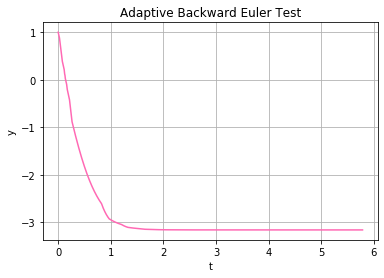

In [9]:
t_values, y_values = backward_euler_adaptive(
    f,
    t0 = 0.0,
    tf = 5.0,
    y0 = 1.0,
    h0 = 0.1,
    tolerance = 1e-5
)

# Print results
print("Final time:", t_values[-1])
print("Final value:", y_values[-1])
print("Expected equilibrium:", -np.sqrt(10))

# Plot
plt.plot(t_values, y_values, color='hotpink')
plt.title("Adaptive Backward Euler Test")
plt.xlabel("t")
plt.ylabel("y")
plt.grid()
plt.show()